# 26 — RSA Analysis (Smorgasbord Atlas)

Representational Similarity Analysis on hyperaligned contrast patterns.

**Questions:**
1. Which contrasts have similar neural representations (RDM geometry)?
2. Does the geometry change across encounters (practice)?
3. How stable is the representational structure across time (second-order RSA)?

In [1]:
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import spearmanr
from sklearn.manifold import MDS

sys.path.insert(0, str(Path.cwd()))
from utils import SUBJECTS

/oak/stanford/groups/russpold/users/nklevak/network_second_modeling/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 3.2.1'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
ANALYSIS_DIR = Path.cwd()
ALIGN_DIR   = ANALYSIS_DIR / "hyperalignment_fmralign_results" / "discovery_sample" / "smorgasbord_parcels"
SAVE_DIR    = ALIGN_DIR / "saved_arrays"
RSA_DIR     = ALIGN_DIR / "rsa"
RSA_DIR.mkdir(exist_ok=True)

train_subjects   = SUBJECTS[:-1]
left_out_subject = SUBJECTS[-1]
print(f"Subjects: {SUBJECTS}")

Subjects: ['sub-s03', 'sub-s10', 'sub-s19', 'sub-s29', 'sub-s43']


In [3]:
aligned_all = {s: np.load(SAVE_DIR / f"aligned_{s}.npy") for s in SUBJECTS}

with open(SAVE_DIR / "shared_tce_sorted.pkl", "rb") as f:
    shared_tce_sorted = pickle.load(f)

print(f"Array shape per subject: {aligned_all[SUBJECTS[0]].shape}  (n_contrasts x n_voxels)")
print(f"Shared tuples: {len(shared_tce_sorted)}")

# Structured access: structured[subj][task][contrast][enc] -> (n_voxels,)
structured = {}
for subj in SUBJECTS:
    structured[subj] = defaultdict(lambda: defaultdict(dict))
    for i, (task, contrast, enc) in enumerate(shared_tce_sorted):
        structured[subj][task][contrast][enc] = aligned_all[subj][i]

Array shape per subject: (159, 172463)  (n_contrasts x n_voxels)
Shared tuples: 159


## 1. Define contrasts of interest

One representative contrast per task. These 8 contrasts form the rows/columns of our RDM.

In [4]:
tasks_to_plot = {
    "stopSignal":        "stop_failure-go",
    "goNogo":            "nogo_success-go",
    "nBack":             "twoBack-oneBack",
    "directedForgetting": "neg-con",
    "cuedTS":            "task_switch_cue_switch-task_stay_cue_stay",
    "spatialTS":         "task_switch_cue_switch-task_stay_cue_stay",
    "shapeMatching":     "main_vars",
    "flanker":           "incongruent-congruent",
}

contrasts_of_interest = [(task, contrast) for task, contrast in tasks_to_plot.items()]
contrast_labels = [task for task in tasks_to_plot]  # short labels for plots
n_contrasts = len(contrasts_of_interest)
enc_strs = [f"{e:02d}" for e in range(1, 6)]

# Check data availability per encounter
print("Data availability per contrast per encounter:")
for task, contrast in contrasts_of_interest:
    avail = []
    for enc in enc_strs:
        has_all = all(enc in structured[s][task].get(contrast, {}) for s in SUBJECTS)
        avail.append(enc if has_all else "--")
    print(f"  {task:22s} {contrast:45s}: {avail}")

Data availability per contrast per encounter:
  stopSignal             stop_failure-go                              : ['01', '02', '03', '04', '05']
  goNogo                 nogo_success-go                              : ['01', '02', '03', '04', '--']
  nBack                  twoBack-oneBack                              : ['01', '02', '03', '04', '05']
  directedForgetting     neg-con                                      : ['01', '02', '03', '04', '05']
  cuedTS                 task_switch_cue_switch-task_stay_cue_stay    : ['01', '02', '03', '04', '--']
  spatialTS              task_switch_cue_switch-task_stay_cue_stay    : ['01', '02', '03', '04', '05']
  shapeMatching          main_vars                                    : ['01', '02', '03', '04', '--']
  flanker                incongruent-congruent                        : ['01', '02', '03', '04', '05']


## 2. Compute RDMs

For each encounter where all contrasts have data for all subjects:
- Per subject: compute `n_contrasts × n_contrasts` RDM using `1 - Pearson r` between contrast spatial patterns
- Average across subjects → group RDM

`1 - Pearson r` = angular dissimilarity between mean-centered patterns (ignores overall magnitude, sensitive only to relative voxel pattern shape).

In [5]:
def compute_rdm(vectors):
    """Compute (n_contrasts x n_contrasts) RDM from (n_contrasts x n_voxels) array.
    Uses 1 - Pearson r as dissimilarity."""
    return squareform(pdist(vectors, metric="correlation"))

group_rdms = {}   # enc -> (n_contrasts, n_contrasts), averaged across subjects
subj_rdms  = {}   # enc -> list of per-subject RDMs
valid_encs = []   # encounters where all contrasts are available for all subjects

for enc in enc_strs:
    rdms_this_enc = []
    for subj in SUBJECTS:
        vectors = []
        skip = False
        for task, contrast in contrasts_of_interest:
            if enc not in structured[subj][task].get(contrast, {}):
                skip = True
                break
            vectors.append(structured[subj][task][contrast][enc])
        if skip:
            break  # if any subject is missing this enc, skip entire encounter
        rdms_this_enc.append(compute_rdm(np.array(vectors)))

    if len(rdms_this_enc) == len(SUBJECTS):
        group_rdms[enc] = np.mean(rdms_this_enc, axis=0)
        subj_rdms[enc]  = rdms_this_enc
        valid_encs.append(enc)
        print(f"Encounter {enc}: computed RDM from {len(rdms_this_enc)} subjects")
    else:
        print(f"Encounter {enc}: SKIPPED (missing data)")

print(f"\nValid encounters for RSA: {valid_encs}")

Encounter 01: computed RDM from 5 subjects
Encounter 02: computed RDM from 5 subjects
Encounter 03: computed RDM from 5 subjects
Encounter 04: computed RDM from 5 subjects
Encounter 05: SKIPPED (missing data)

Valid encounters for RSA: ['01', '02', '03', '04']


## 3. Group-average RDM heatmaps per encounter

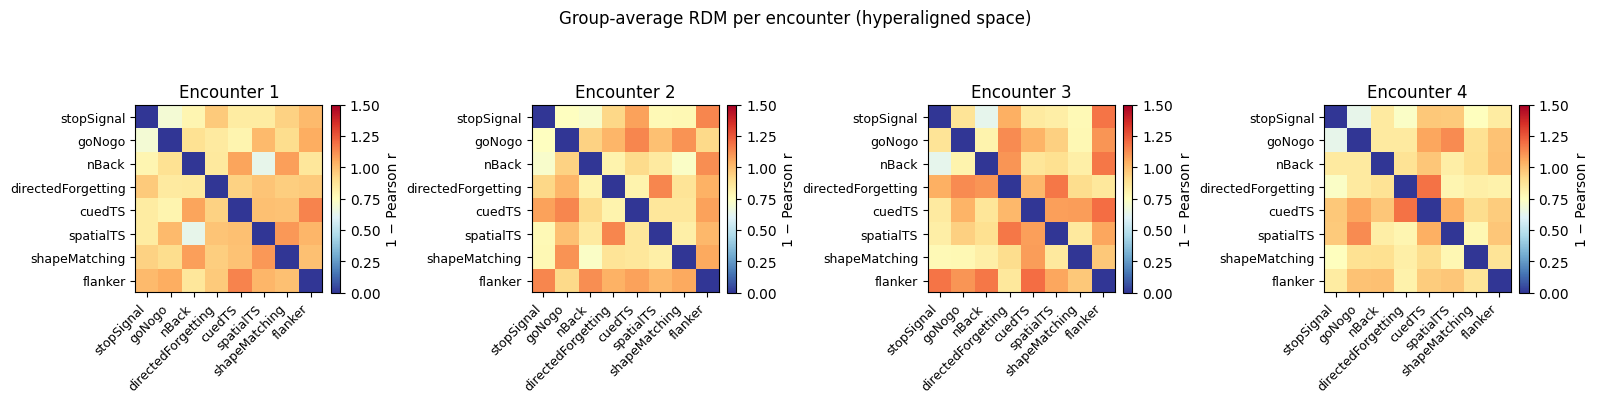

In [6]:
n_enc = len(valid_encs)
fig, axes = plt.subplots(1, n_enc, figsize=(4 * n_enc, 4))
if n_enc == 1:
    axes = [axes]

for ax, enc in zip(axes, valid_encs):
    rdm = group_rdms[enc]
    im = ax.imshow(rdm, vmin=0, vmax=1.5, cmap="RdYlBu_r")
    ax.set_xticks(range(n_contrasts))
    ax.set_yticks(range(n_contrasts))
    ax.set_xticklabels(contrast_labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(contrast_labels, fontsize=9)
    ax.set_title(f"Encounter {int(enc)}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="1 − Pearson r")

plt.suptitle("Group-average RDM per encounter (hyperaligned space)", y=1.02)
plt.tight_layout()
plt.savefig(RSA_DIR / "rdm_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Hierarchical clustering (dendrogram) per encounter

Shows which contrasts cluster together — contrasts with similar neural patterns will merge early.

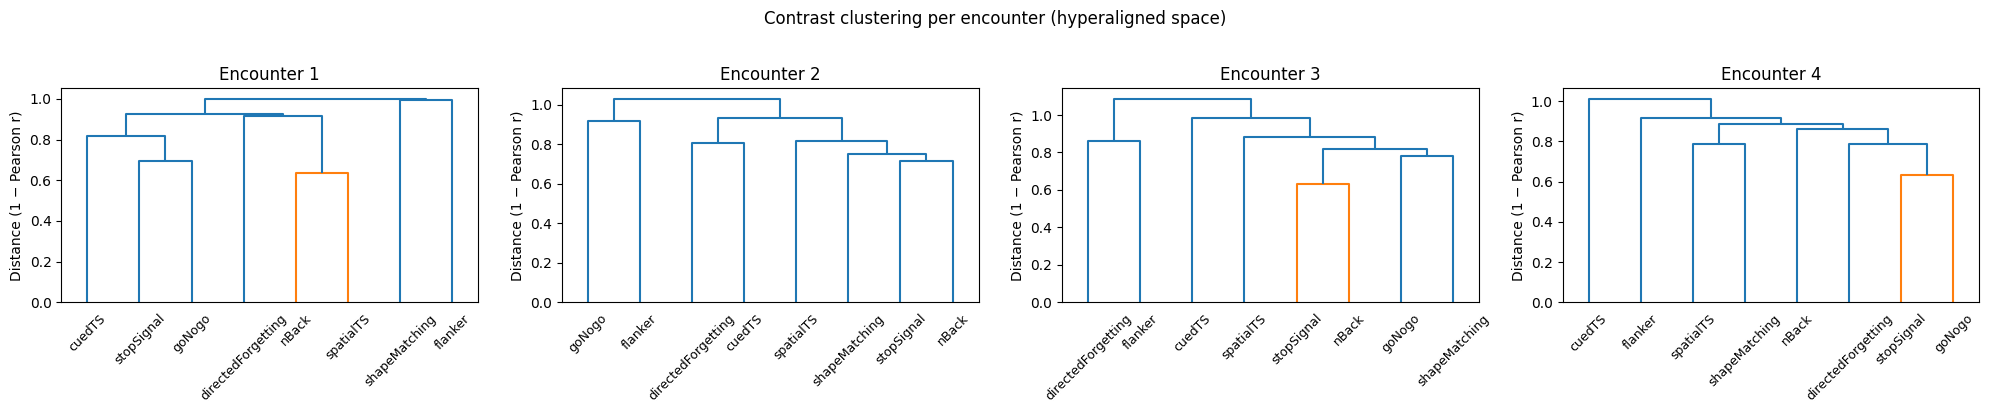

In [7]:
fig, axes = plt.subplots(1, n_enc, figsize=(5 * n_enc, 4))
if n_enc == 1:
    axes = [axes]

for ax, enc in zip(axes, valid_encs):
    rdm = group_rdms[enc]
    condensed = squareform(rdm)  # condensed upper-triangle vector
    Z = linkage(condensed, method="average")
    dendrogram(Z, labels=contrast_labels, ax=ax, leaf_rotation=45,
               leaf_font_size=9, color_threshold=0.6 * condensed.max())
    ax.set_title(f"Encounter {int(enc)}")
    ax.set_ylabel("Distance (1 − Pearson r)")

plt.suptitle("Contrast clustering per encounter (hyperaligned space)", y=1.02)
plt.tight_layout()
plt.savefig(RSA_DIR / "rdm_dendrograms.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Second-order RSA: encounter × encounter

Correlate (Spearman) the off-diagonal RDM elements between every pair of encounters.
High correlation = similar representational geometry at those two time points.

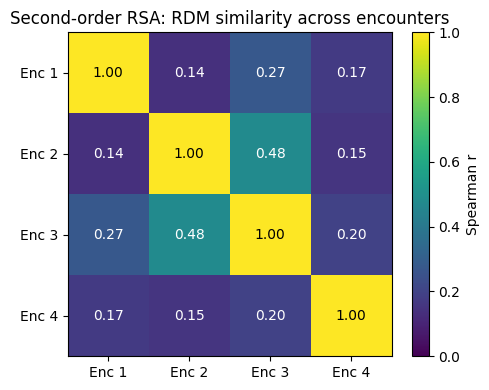

Spearman r matrix:
[[1.    0.14  0.275 0.171]
 [0.14  1.    0.479 0.153]
 [0.275 0.479 1.    0.198]
 [0.171 0.153 0.198 1.   ]]


In [8]:
# Extract upper-triangle of each encounter's RDM
idx = np.triu_indices(n_contrasts, k=1)
enc_vecs = {enc: group_rdms[enc][idx] for enc in valid_encs}

n_v = len(valid_encs)
second_order_r = np.zeros((n_v, n_v))
second_order_p = np.zeros((n_v, n_v))

for i, e1 in enumerate(valid_encs):
    for j, e2 in enumerate(valid_encs):
        r, p = spearmanr(enc_vecs[e1], enc_vecs[e2])
        second_order_r[i, j] = r
        second_order_p[i, j] = p

enc_tick_labels = [f"Enc {int(e)}" for e in valid_encs]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(second_order_r, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(n_v))
ax.set_yticks(range(n_v))
ax.set_xticklabels(enc_tick_labels)
ax.set_yticklabels(enc_tick_labels)
plt.colorbar(im, ax=ax, label="Spearman r")
for i in range(n_v):
    for j in range(n_v):
        ax.text(j, i, f"{second_order_r[i,j]:.2f}", ha="center", va="center",
                color="white" if second_order_r[i,j] < 0.5 else "black", fontsize=10)
ax.set_title("Second-order RSA: RDM similarity across encounters")
plt.tight_layout()
plt.savefig(RSA_DIR / "second_order_rsa.png", dpi=150, bbox_inches="tight")
plt.show()

print("Spearman r matrix:")
print(np.round(second_order_r, 3))

## 6. MDS: representational geometry across encounters

Project the RDM into 2D space (multidimensional scaling). Each point = one contrast.
Animate across encounters to see how the geometry shifts with practice.

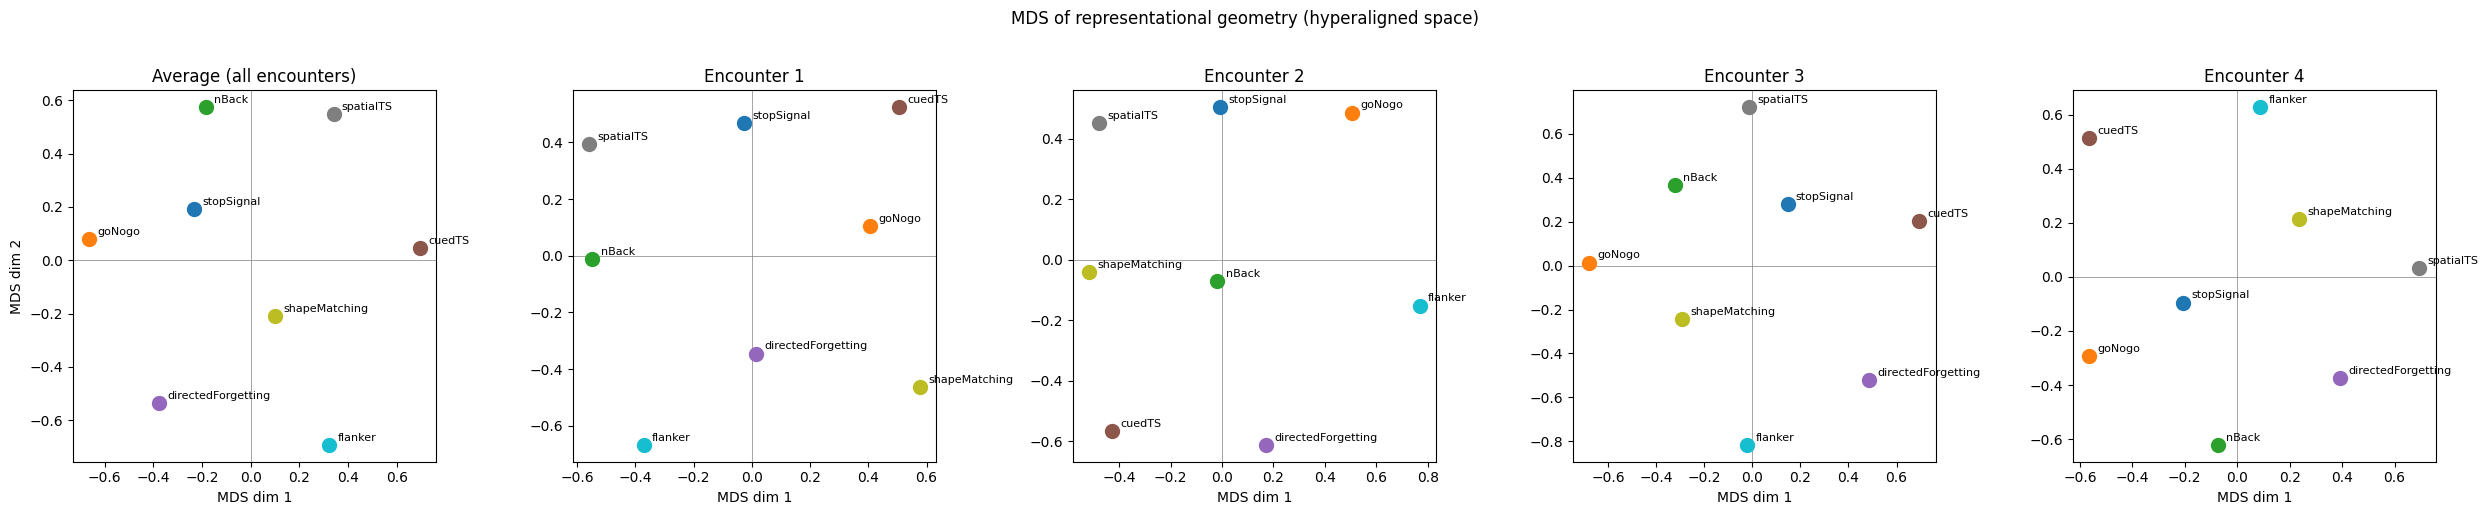

In [9]:
# Fit MDS on the average RDM across encounters for a stable reference frame,
# then project each encounter's RDM separately.

# Use average RDM across encounters as reference for consistent orientation
avg_rdm = np.mean([group_rdms[enc] for enc in valid_encs], axis=0)
mds_ref = MDS(n_components=2, dissimilarity="precomputed", random_state=42, n_init=10)
ref_coords = mds_ref.fit_transform(avg_rdm)

# Fit each encounter separately
mds_coords = {}
for enc in valid_encs:
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, n_init=10)
    mds_coords[enc] = mds.fit_transform(group_rdms[enc])

# Color contrasts by task
task_colors = plt.cm.tab10(np.linspace(0, 1, n_contrasts))

fig, axes = plt.subplots(1, n_enc + 1, figsize=(5 * (n_enc + 1), 5))

# Plot reference (average)
ax = axes[0]
for i, label in enumerate(contrast_labels):
    ax.scatter(*ref_coords[i], color=task_colors[i], s=100, zorder=5)
    ax.annotate(label, ref_coords[i], textcoords="offset points",
                xytext=(6, 3), fontsize=8)
ax.set_title("Average (all encounters)")
ax.set_xlabel("MDS dim 1")
ax.set_ylabel("MDS dim 2")
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

# Plot per encounter
for ax, enc in zip(axes[1:], valid_encs):
    coords = mds_coords[enc]
    for i, label in enumerate(contrast_labels):
        ax.scatter(*coords[i], color=task_colors[i], s=100, zorder=5)
        ax.annotate(label, coords[i], textcoords="offset points",
                    xytext=(6, 3), fontsize=8)
    ax.set_title(f"Encounter {int(enc)}")
    ax.set_xlabel("MDS dim 1")
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)

plt.suptitle("MDS of representational geometry (hyperaligned space)", y=1.02)
plt.tight_layout()
plt.savefig(RSA_DIR / "mds_per_encounter.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Per-subject RDM variability

How much do subjects differ in their representational geometry? 
Plot each subject's RDM alongside the group average to see inter-individual variation.

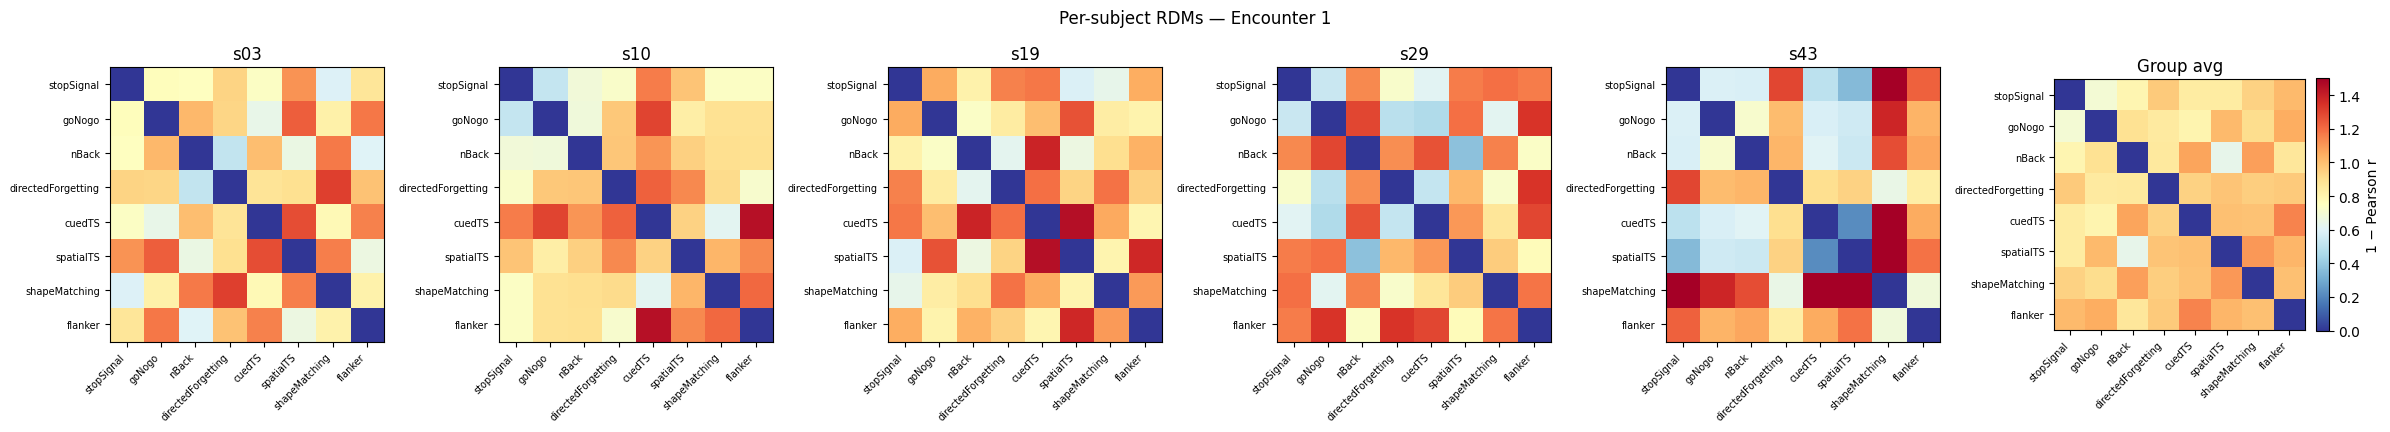

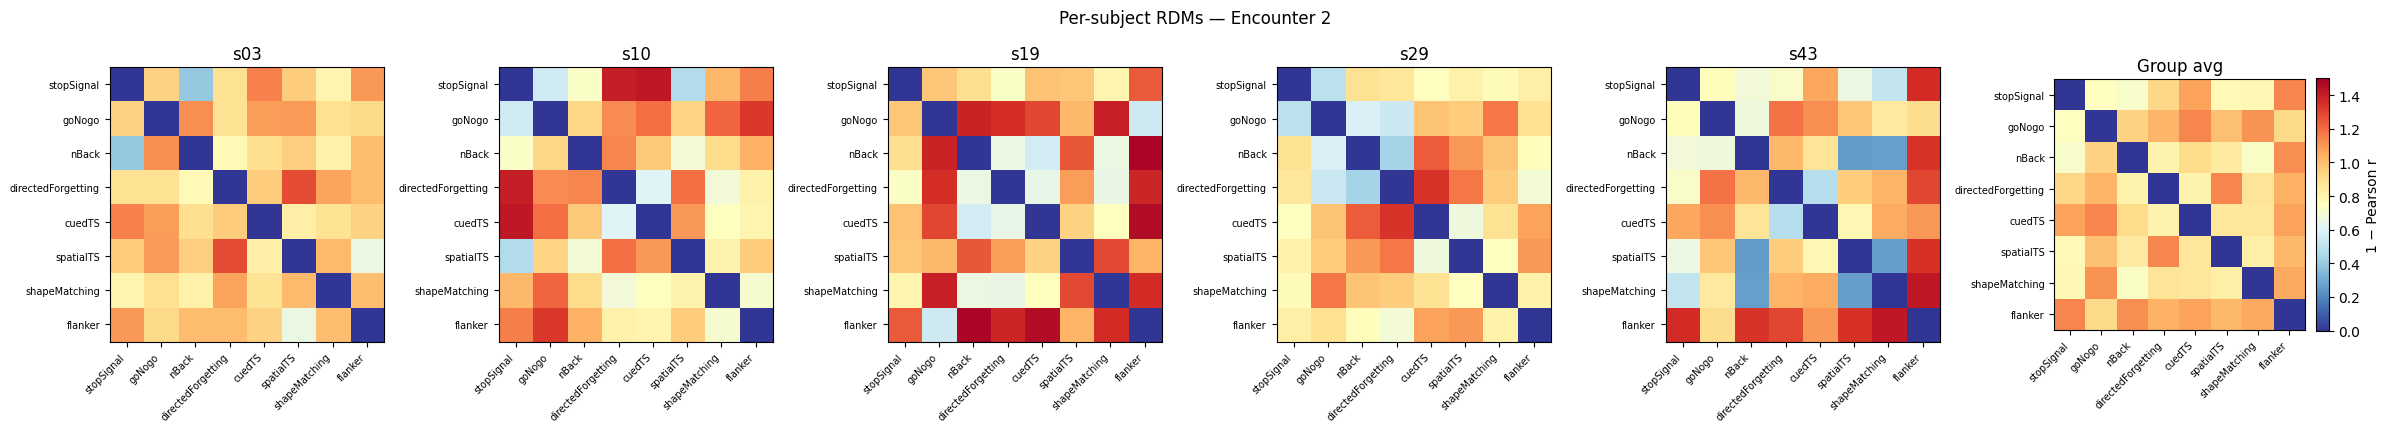

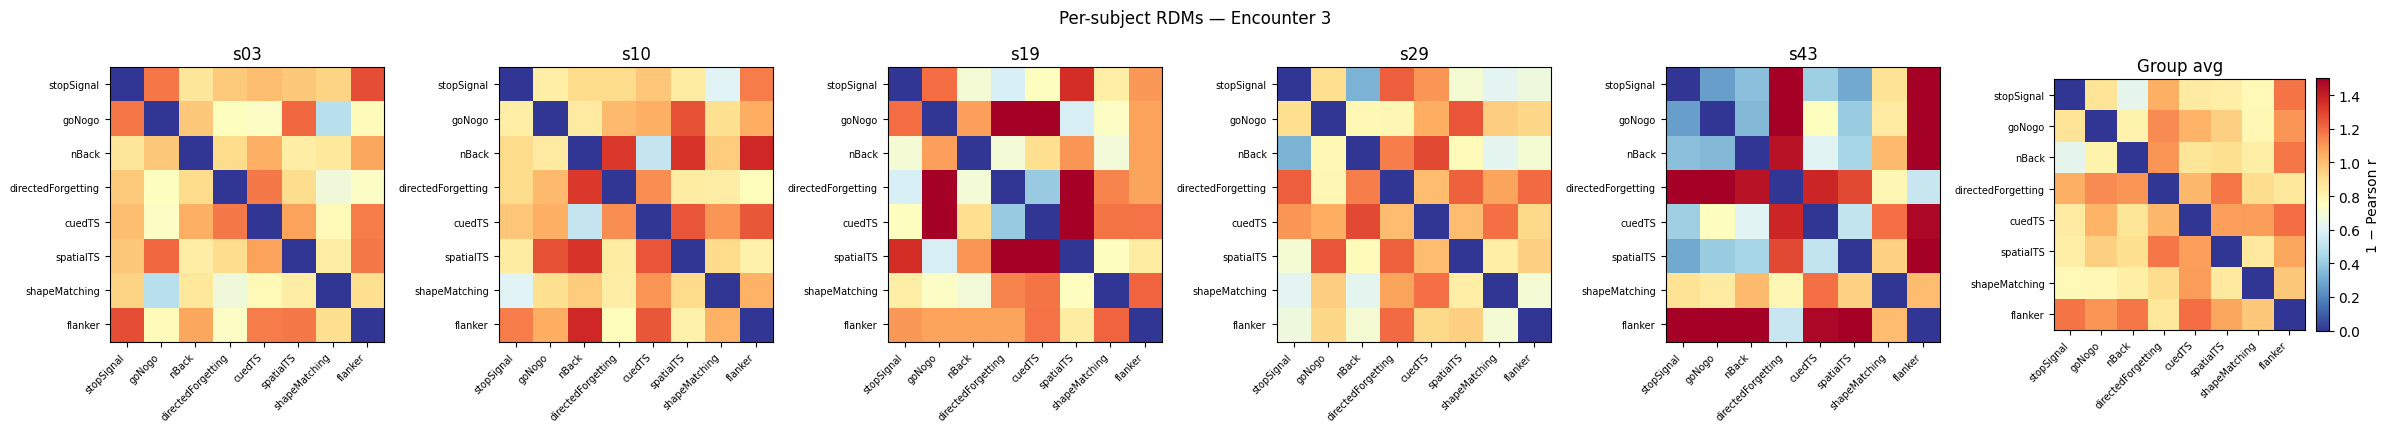

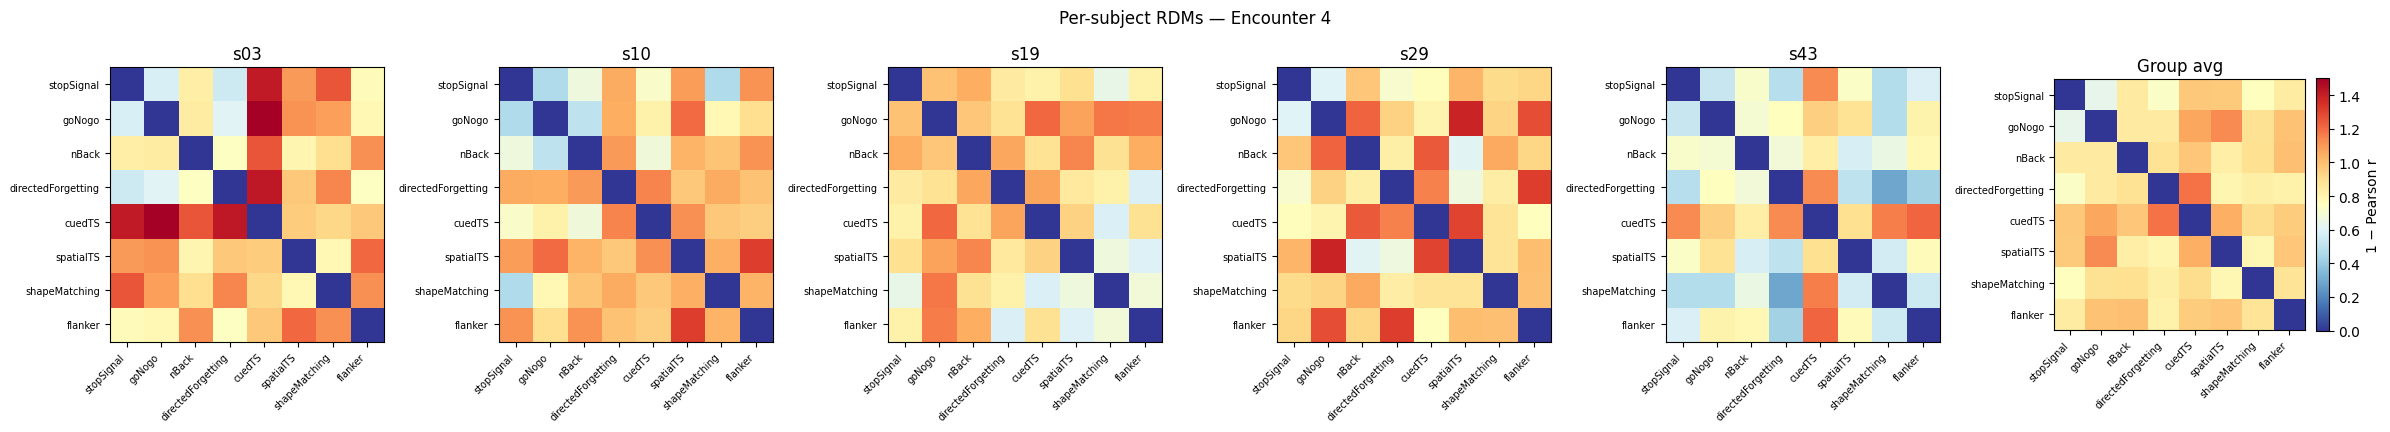

In [10]:
# For each valid encounter, plot all subject RDMs + group average
for enc in valid_encs:
    n_subj = len(SUBJECTS)
    fig, axes = plt.subplots(1, n_subj + 1, figsize=(4 * (n_subj + 1), 4))

    for ax, subj, rdm in zip(axes, SUBJECTS, subj_rdms[enc]):
        im = ax.imshow(rdm, vmin=0, vmax=1.5, cmap="RdYlBu_r")
        ax.set_xticks(range(n_contrasts))
        ax.set_yticks(range(n_contrasts))
        ax.set_xticklabels(contrast_labels, rotation=45, ha="right", fontsize=7)
        ax.set_yticklabels(contrast_labels, fontsize=7)
        ax.set_title(subj[-3:])

    # Group average
    ax = axes[-1]
    im = ax.imshow(group_rdms[enc], vmin=0, vmax=1.5, cmap="RdYlBu_r")
    ax.set_xticks(range(n_contrasts))
    ax.set_yticks(range(n_contrasts))
    ax.set_xticklabels(contrast_labels, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(contrast_labels, fontsize=7)
    ax.set_title("Group avg")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="1 − Pearson r")

    plt.suptitle(f"Per-subject RDMs — Encounter {int(enc)}", y=1.02)
    plt.tight_layout()
    plt.savefig(RSA_DIR / f"rdm_per_subject_enc{enc}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. Distance between specific contrast pairs across encounters

Track how the dissimilarity between selected contrast pairs evolves over time.

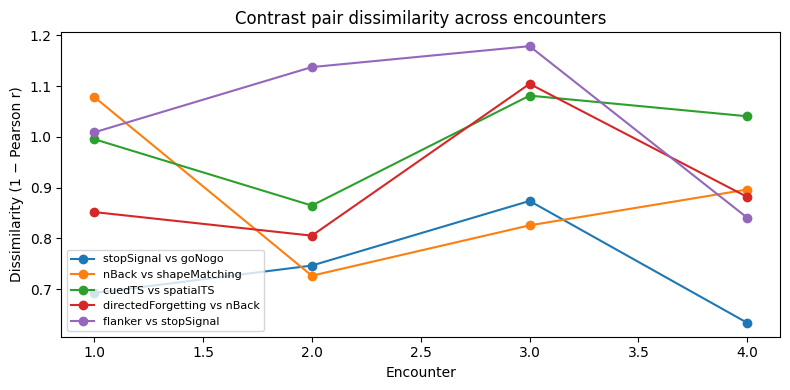

In [11]:
# Pick contrast pairs of theoretical interest
pairs_of_interest = [
    ("stopSignal", "goNogo"),       # both involve response inhibition
    ("nBack", "shapeMatching"),     # both involve working memory / matching
    ("cuedTS", "spatialTS"),        # both are task-switching paradigms
    ("directedForgetting", "nBack"),# both involve cognitive control over memory
    ("flanker", "stopSignal"),      # both involve conflict/inhibition
]

fig, ax = plt.subplots(figsize=(8, 4))

for task_a, task_b in pairs_of_interest:
    idx_a = contrast_labels.index(task_a)
    idx_b = contrast_labels.index(task_b)
    dists = [group_rdms[enc][idx_a, idx_b] for enc in valid_encs]
    ax.plot([int(e) for e in valid_encs], dists, marker="o",
            label=f"{task_a} vs {task_b}")

ax.set_xlabel("Encounter")
ax.set_ylabel("Dissimilarity (1 − Pearson r)")
ax.set_title("Contrast pair dissimilarity across encounters")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RSA_DIR / "contrast_pair_distances.png", dpi=150, bbox_inches="tight")
plt.show()